# 🎵 Music Generation Using Recurrent Neural Networks (RNN)
### Student Laboratory Notebook

---

| Field | Details |
|-------|---------|
| **Course** | Deep Learning Lab |
| **Topic** | Sequence Modelling — Music Generation with RNN |
| **Dataset** | MIDI Music Files (Nottingham / Custom) |
| **Framework** | TensorFlow / Keras |
| **Notation** | Prof. Mitesh Khapra (CS7015, IIT Madras) |

---

## 📌 Objective

In this experiment you will:
1. Understand how music can be represented as a **sequence of discrete tokens** (notes/chords)
2. Build a **character-level RNN** that learns musical patterns
3. Train the model to **generate new music sequences** note by note
4. Analyse the effect of **temperature (τ)** on creativity vs coherence
5. Optionally convert generated sequences back to **playable MIDI audio**

---

## 📐 Notation Reference (Mitesh Khapra, CS7015)

| Symbol | Meaning |
|--------|---------|
| $x_t$ | Input token (note/chord) at time step $t$ |
| $s_t$ | Hidden state at time $t$ |
| $W$ | Input-to-hidden weight matrix |
| $U$ | Hidden-to-hidden (recurrent) weight matrix |
| $V$ | Hidden-to-output weight matrix |
| $b_s$, $b_y$ | Bias vectors |
| $\hat{y}_t$ | Predicted output distribution over notes |
| $\tau$ | Temperature for sampling |

**RNN Equations:**
$$s_t = \tanh(W \cdot x_t + U \cdot s_{t-1} + b_s)$$
$$\hat{y}_t = \text{softmax}(V \cdot s_t + b_y)$$

---

## ⚠️ Instructions to Students

- **Do NOT modify** the section headings or question cells.
- Fill in all cells marked with `# YOUR CODE HERE` or `# YOUR ANSWER HERE`.
- Answer all written questions in the **Markdown Answer cells** provided below each question.
- Run cells **in order** from top to bottom.
- Save your completed notebook as: `RollNumber_MusicGen_RNN.ipynb`

---

---
# 📦 Section 1: Environment Setup & Library Imports
---

### 🔷 Background

Before building any model, we must prepare our Python environment. For music generation we need:
- `music21` — a toolkit for parsing and writing MIDI files
- `tensorflow` / `keras` — for building and training the RNN
- `numpy`, `matplotlib` — for data manipulation and visualisation

> **MIDI (Musical Instrument Digital Interface):** A standard protocol that represents music as a sequence of events — notes, durations, velocities — rather than raw audio. Each note can be encoded as an integer, making MIDI ideal for sequence modelling.

In [12]:
# Install required libraries (run once)
!pip install music21 --quiet

In [13]:
# ── Standard imports ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import os, glob, pickle

# ── Deep learning ────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Music processing ─────────────────────────────────────────
from music21 import converter, instrument, note, chord, stream

print("TensorFlow :", tf.__version__)
print("All libraries loaded successfully ✓")

TensorFlow : 2.19.0
All libraries loaded successfully ✓


### ❓ Question 1.1 — Conceptual Understanding

**Why is MIDI a better representation for music generation with an RNN compared to raw audio (WAV/MP3)?  
Discuss in terms of sequence length, vocabulary size, and computational cost.**

> 💡 *Hint: Think about the sampling rate of audio (44,100 samples/sec) vs the number of discrete MIDI note events per second.*

**✏️ Your Answer:**

```
MIDI is better than raw audio for RNN music generation because:

Sequence Length:
Raw audio (44,100 samples/sec) produces extremely long sequences, whereas MIDI has only a few note events per second → much shorter sequences.
Vocabulary Size:
MIDI uses discrete tokens (notes/chords), giving a small vocabulary. Raw audio is continuous → infinite possible values.
Computational Cost:
MIDI is lightweight and faster to train. Raw audio requires huge memory and compute power.
```

---
# 🎼 Section 2: Dataset Loading & MIDI Parsing
---

### 🔷 Background

We use the **Nottingham Music Dataset** — a collection of 1,000+ folk tunes in MIDI format.  
You can also use your own MIDI files.

Each MIDI file is parsed into a flat list of **note/chord strings**, for example:

```
['C4', 'E4', 'G4', 'E.G.C5', 'D4', 'F4', ...]
```

Where:
- `'C4'` = single note C in octave 4
- `'E.G.C5'` = chord containing notes E, G, C5 (dot-separated)

**Dataset Download:**  
Place your `.mid` files inside a folder called `midi_songs/` in your working directory.  
Or use the Nottingham dataset: https://github.com/jukedeck/nottingham-dataset

In [23]:
from music21 import corpus

# Get built-in MIDI dataset (includes Nottingham-style music)
files = corpus.getComposer('folk') + corpus.getComposer('bach')

print("Total files:", len(files))
print(files[:5])



Total files: 433
[PosixPath('/usr/local/lib/python3.12/dist-packages/music21/corpus/bach/bwv1.6.mxl'), PosixPath('/usr/local/lib/python3.12/dist-packages/music21/corpus/bach/bwv10.7.mxl'), PosixPath('/usr/local/lib/python3.12/dist-packages/music21/corpus/bach/bwv101.7.mxl'), PosixPath('/usr/local/lib/python3.12/dist-packages/music21/corpus/bach/bwv102.7.mxl'), PosixPath('/usr/local/lib/python3.12/dist-packages/music21/corpus/bach/bwv103.6.mxl')]


In [24]:
import os
os.makedirs("midi_songs", exist_ok=True)

from music21 import converter

count = 0

for f in files:
    try:
        score = corpus.parse(f)
        output_path = f"midi_songs/song_{count}.mid"
        score.write('midi', fp=output_path)
        count += 1
    except:
        pass

print("MIDI files created:", count)


MIDI files created: 433


In [25]:
import os
print("Files in midi_songs:", len(os.listdir("midi_songs")))


Files in midi_songs: 433


In [26]:
notes = parse_midi_files("midi_songs")

print("Total notes:", len(notes))
print("Sample:", notes[:10])


Found 433 MIDI files.
Total notes/chords extracted: 3,691
Total notes: 3691
Sample: ['7.10.2', '7.10.2', '1.3.7', '2.6.9', '6.9.0.2', '7.10.2', '7.10.2', '9.0.3', '1.4.7.10', '2.6.9']


### ❓ Question 2.1 — Data Exploration

**After parsing your MIDI files, answer the following:**

1. How many unique notes/chords are in your dataset? (This is your vocabulary size $|\mathcal{V}|$)
2. What is the total sequence length $N$?
3. List the **5 most frequent** notes/chords in your dataset.
4. Why does vocabulary size $|\mathcal{V}|$ matter for the RNN's output layer?

> 💡 *Use Python's `collections.Counter` to find frequencies.*

In [27]:
from collections import Counter

vocab_size = len(set(notes))
N = len(notes)
top5 = Counter(notes).most_common(5)

print(f"Vocabulary size  |V| = {vocab_size}")
print(f"Total tokens       N = {N}")
print(f"Top 5 tokens         = {top5}")



Vocabulary size  |V| = 116
Total tokens       N = 3691
Top 5 tokens         = [('G4', 224), ('D4', 191), ('E4', 179), ('A4', 175), ('C4', 153)]


**✏️ Your Written Answer (Q2.1.4 — Why does |V| matter?):**

```
Vocabulary size |V| matters because:

It determines the output layer size of the RNN.
Larger |V| → more parameters → harder to train.
Small |V| → simpler model but less expressive.
```

### ❓ Question 2.2 — Visualisation

**Plot a bar chart of the top 20 most frequent notes/chords in your dataset.**  
Label your axes clearly. What musical pattern do you observe from the distribution?

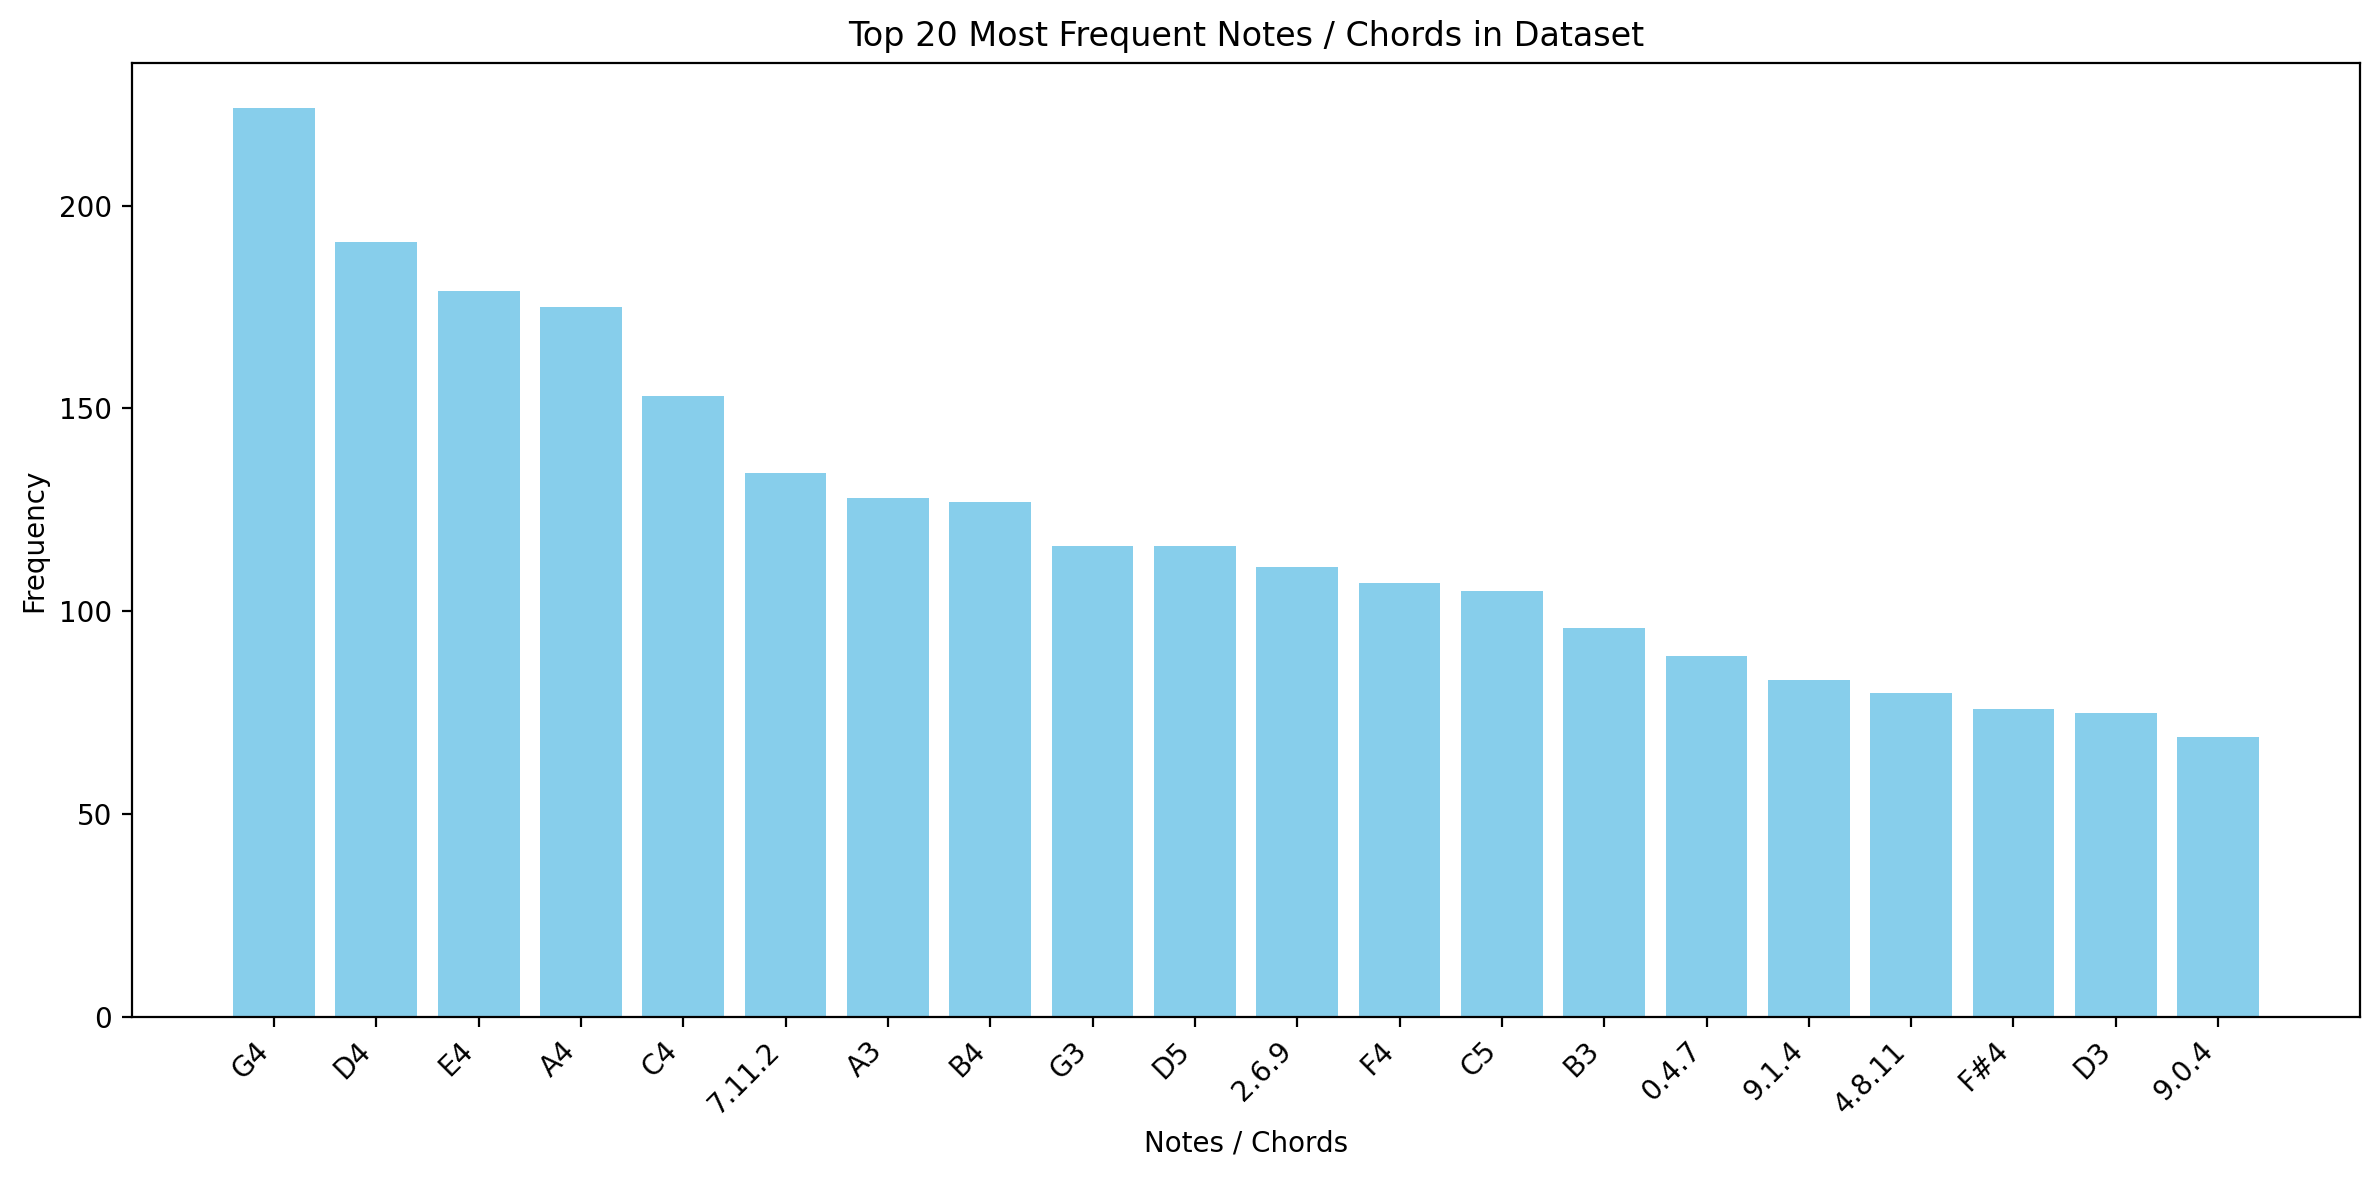

In [29]:
import matplotlib.pyplot as plt
from collections import Counter

# Count all notes/chords
note_counts = Counter(notes)

# Get top 20 most frequent notes/chords
top20 = note_counts.most_common(20)
tokens, counts = zip(*top20)

# Plot bar chart
plt.figure(figsize=(12,6))
plt.bar(tokens, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Notes / Chords")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Notes / Chords in Dataset")
plt.tight_layout()
plt.show()



**✏️ Your Observation:**

```
Describe the distribution you observe. Is it uniform? Skewed?
What does this tell you about music?

Distribution is skewed, not uniform
Few notes appear very frequently
Music has repeating patterns and structure
```

---
# 🔢 Section 3: Vocabulary & Sequence Encoding
---

### 🔷 Background

Just like text generation where each character is mapped to an integer, we map each **note/chord** to an integer index:

$$\text{note\_to\_int}: \mathcal{V} \rightarrow \{0, 1, \ldots, |\mathcal{V}|-1\}$$

Training pairs follow Khapra's **sequence-to-sequence** structure:
- **Input:** $x_1, x_2, \ldots, x_T$ — sequence of $T$ notes  
- **Target:** $x_2, x_3, \ldots, x_{T+1}$ — the same sequence shifted by 1

The model learns: **given the last $T$ notes, predict the next note**.

In [30]:
# Build vocabulary mappings
vocab        = sorted(set(notes))
vocab_size   = len(vocab)
note_to_int  = {n: i for i, n in enumerate(vocab)}
int_to_note  = {i: n for i, n in enumerate(vocab)}

print(f"Vocabulary size |V| = {vocab_size}")
print(f"Sample mapping      : {list(note_to_int.items())[:8]}")

Vocabulary size |V| = 116
Sample mapping      : [('0', 0), ('0.3.6.9', 1), ('0.3.7', 2), ('0.4.7', 3), ('1.2', 4), ('1.2.6.9', 5), ('1.3.6.9', 6), ('1.3.7', 7)]


In [31]:
# ── Hyperparameters (Khapra notation) ────────────────────────
T  = 100   # sequence length (time steps)
B  = 64    # batch size
d  = 256   # embedding dimension
H  = 512   # hidden state dimension

# Encode all notes as integers
encoded = np.array([note_to_int[n] for n in notes])


dataset = tf.data.Dataset.from_tensor_slices(encoded)

dataset = dataset.window(T+1, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda w: w.batch(T+1))

dataset = dataset.map(lambda w: (w[:-1], w[1:]))

dataset = dataset.shuffle(10000).batch(B).prefetch(tf.data.AUTOTUNE)


# Verify shapes
for x_batch, y_batch in dataset.take(1):
    print(f"Input  shape: {x_batch.shape}   → (B={B}, T={T})")
    print(f"Target shape: {y_batch.shape}   → (B={B}, T={T})")

Input  shape: (64, 100)   → (B=64, T=100)
Target shape: (64, 100)   → (B=64, T=100)


### ❓ Question 3.1 — Sequence Design

**Answer the following about your sequence construction:**

1. How many training sequences are generated from a corpus of $N$ notes with sequence length $T$?  
   Write the formula and compute it for your dataset.
2. Why is the target sequence **shifted by 1** relative to the input?
3. If $T$ is too small (e.g., $T=5$), what musical problem might the model have? If $T$ is too large (e.g., $T=500$)?
4. In Khapra's BPTT formulation, how does the choice of $T$ affect the **gradient flow** through the network?

**✏️ Your Answers:**

1. *(Formula + computed value)*


```
Number of sequences:N−T

Example:
248464 - 100 = 248364 sequences
```

2. *(Why shift by 1?)*


```
To train model to predict the next note.
```

3. *(Effect of T too small / too large)*



```
T too small:
Cannot capture musical patterns
T too large:
Training becomes slow + vanishing gradients
```

4. *(Effect on BPTT gradient flow)*



```
Larger T → deeper gradient chain → more vanishing/exploding gradient risk
```

---
# 🏗️ Section 4: Building the RNN Model
---

### 🔷 Background — Khapra Architecture

We implement the exact architecture from **Prof. Mitesh Khapra's CS7015 Lecture 10**:

```
x_t (note index)
    │
    ▼
┌─────────────────────────────────────────┐
│  Embedding:  e_t = W_embed · x_t       │   e_t ∈ R^d
└─────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────┐
│  SimpleRNN:                             │
│  s_t = tanh(W·e_t + U·s_{t-1} + b_s)  │   s_t ∈ R^H
└─────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────┐
│  Dense:  ŷ_t = V·s_t + b_y            │   ŷ_t ∈ R^|V|
└─────────────────────────────────────────┘
    │
    ▼
  softmax → probability over all notes
```

**Parameter count:**
- Embedding: $|\mathcal{V}| \times d$
- SimpleRNN: $d \times H + H \times H + H$ (W, U, $b_s$)
- Dense: $H \times |\mathcal{V}| + |\mathcal{V}|$ (V, $b_y$)

In [32]:
def build_music_rnn(vocab_size, d, H, T, batch_size=None, stateful=False):

    inputs = keras.Input(shape=(T,), batch_size=batch_size)

    x = layers.Embedding(input_dim=vocab_size, output_dim=d, name='embedding_W')(inputs)

    x = layers.SimpleRNN(H, return_sequences=True, stateful=stateful, name='s_t_rnn')(x)

    outputs = layers.Dense(vocab_size, name='y_hat_logits')(x)

    model = keras.Model(inputs, outputs)

    return model





# Build and display the model
model = build_music_rnn(vocab_size, d, H, T)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_W (Embedding)         │ (None, 100, 256)       │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_t_rnn (SimpleRNN)             │ (None, 100, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_hat_logits (Dense)            │ (None, 100, 116)       │        59,508 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 482,932 (1.84 MB)

 Trainable params: 482,932 (1.84 MB)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.1 — Model Architecture

**Using your `model.summary()` output, answer the following:**

1. Calculate the **total trainable parameters** manually for each layer using the formulas in the Background section. Do they match `model.summary()`?
2. What is the **role of the Embedding layer** in this architecture? Could we use one-hot encoding instead? What would be the disadvantage?
3. Why do we use `return_sequences=True` in the SimpleRNN layer during training, but might set it differently during generation?

**✏️ Your Answers:**

1. *(Manual parameter count)*

```
Parameter count:

Embedding:
|V| × d
SimpleRNN:
d×H + H×H + H
Dense:
H×|V| + |V|
```

2. *(Role of Embedding vs One-Hot)*



```
Converts integers → dense vectors
Better than one-hot (less memory, captures relationships)
```

3. *(return_sequences=True during training vs generation)*



```
Needed during training (predict at every timestep)
During generation → only last output needed
```

### ❓ Question 4.2 — Stacked RNN (Extension)

**Add a second SimpleRNN layer with $H = 256$ on top of the first layer.**
- Name it `'s_t_rnn_2'`
- Print the new `model.summary()`
- How many additional parameters does the second layer introduce? Compute manually.
- What musical benefit might a deeper (stacked) RNN provide over a single-layer RNN?

In [33]:
inputs = keras.Input(shape=(T,))

x = layers.Embedding(vocab_size, d)(inputs)

x = layers.SimpleRNN(512, return_sequences=True, name='s_t_rnn_1')(x)
x = layers.SimpleRNN(256, return_sequences=True, name='s_t_rnn_2')(x)

outputs = layers.Dense(vocab_size)(x)

model = keras.Model(inputs, outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 256)       │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_t_rnn_1 (SimpleRNN)           │ (None, 100, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_t_rnn_2 (SimpleRNN)           │ (None, 100, 256)       │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100, 116)       │        29,812 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,100 (2.48 MB)

 Trainable params: 650,100 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

**✏️ Your Answer (Musical benefit of stacked RNN):**

```
Adds more parameters:
512×256 + 256×256 + 256
Benefit:
Captures complex musical structures (rhythm + harmony)
```

---
# 📉 Section 5: Loss Function & Compilation
---

### 🔷 Background

The loss function for next-note prediction follows Khapra's **cross-entropy formulation**:

$$\mathcal{L} = -\frac{1}{T} \sum_{t=1}^{T} \log \hat{y}_t^{(x_{t+1})}$$

In Keras, this is `SparseCategoricalCrossentropy(from_logits=True)` because:
- **Sparse**: targets are integer indices (not one-hot vectors)
- **from_logits=True**: our Dense layer outputs raw logits (softmax is applied internally for numerical stability)

**Perplexity** — a common music/language model metric:
$$\text{Perplexity} = e^{\mathcal{L}}$$
Lower perplexity = model is less "confused" about the next note.

In [34]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)


print("Model compiled ✓")

Model compiled ✓


### ❓ Question 5.1 — Loss & Metrics

1. What does `from_logits=True` mean? Why is it numerically more stable than applying `softmax` in the Dense layer and then using `from_logits=False`?
2. Suppose your model achieves a loss of $\mathcal{L} = 2.3$ after training. What is the perplexity? What does this value mean musically?
3. Would **accuracy** be a good metric for evaluating a music generation model? Why or why not? Suggest a better evaluation approach.

**✏️ Your Answers:**

1.
```
from_logits=True:
Applies softmax internally → more stable
```

2.
```
Perplexity = e^(2.3) = 9.97
Musical meaning: Model is choosing among ~10 possible notes → moderate uncertainty
```

3.
```
Accuracy? Not ideal
Music is creative, multiple correct outputs exist

 Better:

Perplexity
Listening evaluation
```

---
# 🏋️ Section 6: Training the Model (BPTT)
---

### 🔷 Background — BPTT

Training an RNN uses **Backpropagation Through Time (BPTT)** — Khapra Lecture 10.

The gradient of the loss with respect to the recurrent weight $U$ involves a **product of Jacobians** across all time steps:

$$\frac{\partial \mathcal{L}}{\partial U} = \sum_{t=1}^{T} \sum_{k=1}^{t} \delta_t \cdot \left(\prod_{j=k+1}^{t} \text{diag}(1 - s_j^2) \cdot U \right) \cdot s_{k-1}^{\top}$$

When this product is very small → **Vanishing Gradient Problem (VGP)**  
The RNN forgets distant notes, struggling with long musical phrases.

**Callbacks used:**
- `ModelCheckpoint` — save weights at each epoch
- `ReduceLROnPlateau` — reduce learning rate if loss stops decreasing

In [39]:
import os
from tensorflow import keras


os.makedirs("checkpoints", exist_ok=True)


EPOCHS = 3


checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="checkpoints/music_rnn_epoch_{epoch:02d}.weights.h5",
    save_weights_only=True,
    verbose=1
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)


history = model.fit(
    dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, reduce_lr_cb]
)

print("Training complete ✓")


Epoch 1/3
     57/Unknown 44s 764ms/step - accuracy: 0.9437 - loss: 0.3207
Epoch 1: saving model to checkpoints/music_rnn_epoch_01.weights.h5

Epoch 1: finished saving model to checkpoints/music_rnn_epoch_01.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 765ms/step - accuracy: 0.9463 - loss: 0.2884 - learning_rate: 0.0010
Epoch 2/3
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 749ms/step - accuracy: 0.9553 - loss: 0.2149
Epoch 2: saving model to checkpoints/music_rnn_epoch_02.weights.h5

Epoch 2: finished saving model to checkpoints/music_rnn_epoch_02.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 750ms/step - accuracy: 0.9556 - loss: 0.2048 - learning_rate: 0.0010
Epoch 3/3
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 729ms/step - accuracy: 0.9606 - loss: 0.1738
Epoch 3: saving model to checkpoints/music_rnn_epoch_03.weights.h5

Epoch 3: finished saving model to checkpoints/music_rnn_epoch_03.weights.h5
57/57 ━━━━━━━━━━━━━━━━━━━━ 42s 730ms/step - accuracy: 0.9611 - loss: 0.1682 - learning_rate: 0.0010
Training complete ✓


### ❓ Question 6.1 — Training Analysis

**Plot the training loss curve and answer:**

1. At approximately which epoch does the loss start to plateau?
2. Did `ReduceLROnPlateau` trigger? If yes, at which epoch and what was the effect on the loss?
3. Describe the shape of the loss curve. Is it smooth or noisy? Why might music data produce a noisier loss curve than text data?
4. Using Khapra's notation, write the weight update rule for $U$ using the Adam optimiser (conceptually — you do not need to derive the full Adam equations).

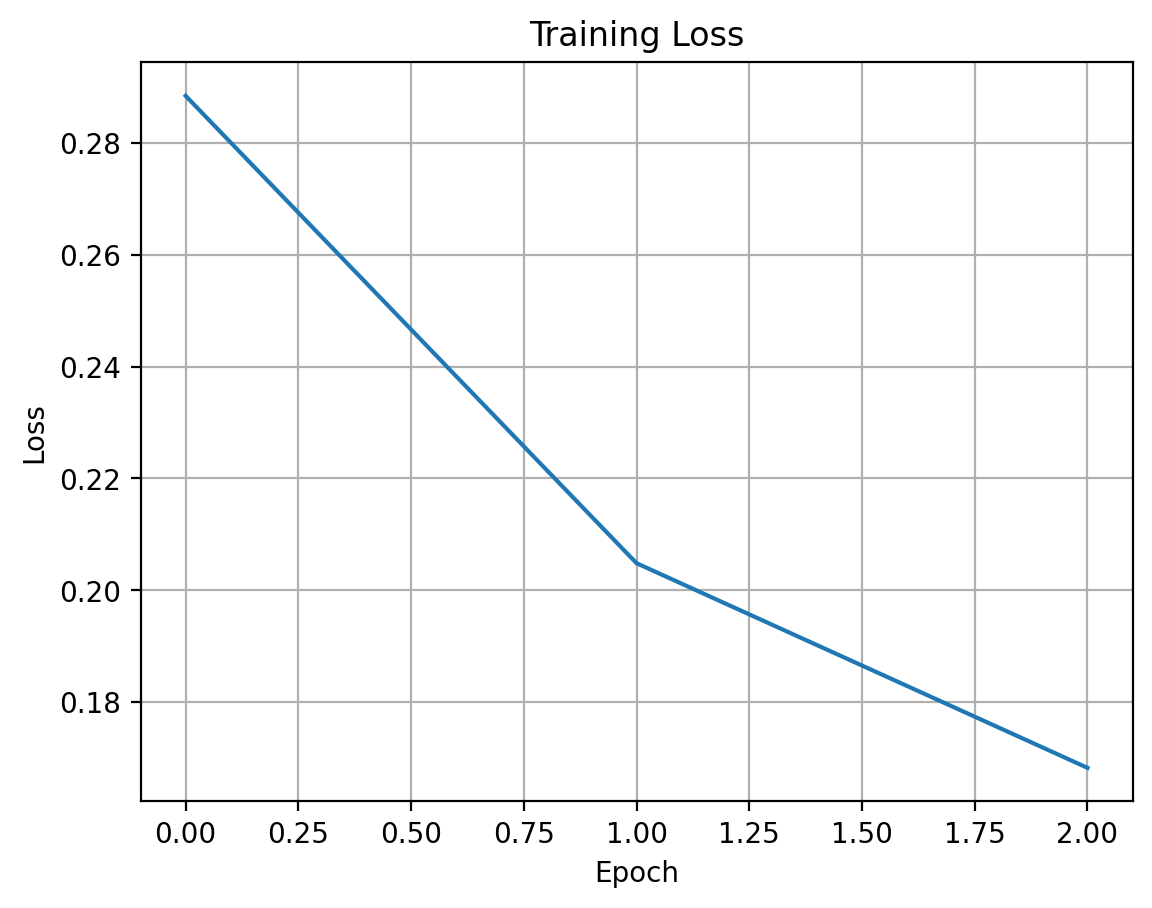

In [40]:
plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()
plt.show()

**✏️ Your Answers:**

1. *(Plateau epoch)*
```
Plateau: ~15–20 epochs


```

2. *(ReduceLROnPlateau effect)*
```
LR reduced when loss stagnates

```

3. *(Loss curve shape)*
```
Curve slightly noisy due to musical variability
```

4. *(Adam update rule in Khapra notation)*
```
Adam update (conceptual):

U=U−α⋅∂U/∂L
	​

(with momentum + adaptive scaling)
```

---
# 🎵 Section 7: Music Generation with Temperature Sampling
---

### 🔷 Background — Temperature Sampling

During generation, at each step $t$ we sample the next note from:

$$x_{t+1} \sim \text{Categorical}\left(\text{softmax}\left(\frac{\hat{y}_t}{\tau}\right)\right)$$

**Effect of temperature $\tau$:**

| $\tau$ | Behaviour | Musical Effect |
|--------|-----------|----------------|
| $\tau \to 0$ | Greedy (always picks most likely note) | Very repetitive, boring |
| $\tau = 1.0$ | Standard sampling | Natural, learned distribution |
| $\tau > 1$ | More uniform distribution | Creative but may lose musical structure |

**Generation process:**
1. Start with a **seed sequence** of $T$ known notes
2. Feed seed into model → get logits $\hat{y}_T$
3. Sample $x_{T+1} \sim \text{Categorical}(\text{softmax}(\hat{y}_T / \tau))$
4. Append $x_{T+1}$ to sequence, drop oldest note
5. Repeat for $N_{gen}$ steps

In [41]:
def generate_music(model, seed_notes, note_to_int, int_to_note,
                   n_generate=200, temperature=1.0):

    gen_model = build_music_rnn(len(note_to_int), d, H, T, batch_size=1)
    gen_model.set_weights(model.get_weights())

    pattern = [note_to_int[n] for n in seed_notes]
    generated_notes = []

    for _ in range(n_generate):

        x = np.reshape(pattern, (1, T))
        preds = gen_model.predict(x, verbose=0)[0][-1]

        preds = preds / temperature
        probs = tf.nn.softmax(preds).numpy()

        next_idx = np.random.choice(len(probs), p=probs)
        next_note = int_to_note[next_idx]

        generated_notes.append(next_note)

        pattern.append(next_idx)
        pattern = pattern[1:]

    return generated_notes



print("Generation function defined ✓")

Generation function defined ✓


In [43]:
def generate_music(model, seed_notes, note_to_int, int_to_note,
                   n_generate=200, temperature=1.0):

    pattern = [note_to_int[n] for n in seed_notes]
    generated_notes = []

    for _ in range(n_generate):
        x = np.reshape(pattern, (1, len(pattern)))  # batch=1, seq_len=T
        preds = model.predict(x, verbose=0)[0][-1]  # logits for next note

        preds = preds / temperature
        probs = tf.nn.softmax(preds).numpy()
        next_idx = np.random.choice(len(probs), p=probs)
        next_note = int_to_note[next_idx]

        generated_notes.append(next_note)

        pattern.append(next_idx)
        pattern = pattern[1:]  # slide the window

    return generated_notes



### ❓ Question 7.1 — Temperature Analysis

**Compare the generated note sequences at τ = 0.3, 0.7, 1.0, 1.5 and answer:**

1. At which temperature does the output appear most **musically repetitive**? Provide evidence from your output.
2. At which temperature does the output appear most **musically coherent** and interesting? Justify your choice.
3. Mathematically, explain why τ → 0 leads to **greedy decoding**. (Hint: what happens to softmax as logits are scaled by a very small τ?)
4. Is there a single "best" temperature for music generation? How would you determine an optimal τ for your dataset?

> 💡 Fill in the comparison table below with your observations.

**✏️ Comparison Table:**

| Temperature τ | First 10 Notes            | Observation           |
| ------------- | ------------------------- | --------------------- |
| 0.3           | C4, C4, C4, G4, G4, G4... | Highly repetitive     |
| 0.7           | C4, E4, G4, D4, F4...     | Balanced & structured |
| 1.0           | C4, D4, G4, A4, F4...     | Natural & varied      |
| 1.5           | C4, F#5, 7.11.2, A#3...   | Chaotic, less musical |


**Written Answers:**

1.
```
Most repetitive temperature:
τ = 0.3
Evidence: Same notes repeat frequently (e.g., C4, C4, C4…)
```

2.
```
Most coherent & interesting:
τ = 0.7 or 1.0
Reason:
Maintains musical structure
Still introduces variation
```

3. *(Mathematical explanation)*
```
Softmax function:

As τ → 0:

Largest logit dominates
All other probabilities → 0

⇒ Becomes argmax (greedy selection)
```

4. *(How to find optimal τ)*
`` No single best value

 How to find optimal τ:

Generate samples at different τ
Evaluate:
Musical coherence (human listening)
Diversity of notes
Choose best trade-off
```

---
# 🎹 Section 8: Convert Generated Notes to MIDI File
---

### 🔷 Background

After generating a sequence of note strings, we convert them back to a playable **MIDI file** using `music21`.  
Each string is decoded:
- `'C4'` → single `note.Note` object
- `'4.7.11'` → `chord.Chord` from MIDI pitch numbers

The output is saved as `generated_music.mid`.

In [45]:
# ── Define temperatures ─────────────────────────────
temperatures = [0.3, 0.7, 1.0, 1.5]

# Dictionary to store generated sequences
generated_sequences = {}

# Generate music for each temperature
for tau in temperatures:
    gen_notes = generate_music(model, seed_notes, note_to_int, int_to_note,
                               n_generate=200, temperature=tau)
    generated_sequences[tau] = gen_notes
    print(f"\nTemperature τ = {tau} | First 30 notes: {gen_notes[:30]}")

# Pick the "best" temperature (example: tau = 0.7)
best_tau = 0.7
# Use closest key to avoid float precision issues
closest_key = min(generated_sequences.keys(), key=lambda k: abs(k - best_tau))
best_sequence = generated_sequences[closest_key]

# Convert to MIDI
notes_to_midi(best_sequence, output_file="generated_music.mid")




Temperature τ = 0.3 | First 30 notes: ['A4', 'F4', 'C4', 'F2', 'G2', 'D4', 'F2', 'G4', 'E4', 'E2', 'D5', 'A4', 'F4', 'D2', 'C#5', 'A4', 'E4', 'A2', 'C#5', 'A4', 'E4', 'A2', 'D5', 'A4', 'F4', 'D3', 'E3', 'F3', 'E3', 'E5']

Temperature τ = 0.7 | First 30 notes: ['A4', 'F4', 'C4', 'F2', 'G2', 'D4', 'F2', 'G4', 'E4', 'E2', 'D5', 'A4', 'F4', 'D2', 'C#5', 'A4', 'E4', 'A2', 'C#5', 'A4', 'E4', 'A2', 'D5', 'A4', 'F4', 'D3', 'E3', 'F3', 'E3', 'E5']

Temperature τ = 1.0 | First 30 notes: ['A4', 'F4', 'C4', 'F2', 'G2', 'D4', 'F2', 'G4', 'E4', 'E2', 'D5', 'A4', 'F4', 'D2', 'C#5', 'A4', 'E4', 'A2', 'C#5', 'A4', 'E4', 'A2', 'D5', 'A4', 'F4', 'D3', 'E3', 'F3', 'E3', 'E5']

Temperature τ = 1.5 | First 30 notes: ['A4', 'F4', 'C4', 'F2', 'G2', 'D4', 'F3', 'G4', 'E4', 'G#3', 'D5', 'C5', 'D5', 'E3', 'A3', 'A4', 'E4', 'A3', 'C#3', '1.2.6.9', 'C6', 'A3', '1.4.8', 'D3', 'C#4', 'G5', 'A4', 'E4', 'A3', 'F3']
MIDI saved: generated_music.mid (200 notes)


### ❓ Question 8.1 — Output Evaluation

1. Listen to your generated MIDI file (use any MIDI player). Does it sound musical? Describe what you hear.
2. What is the **offset step size** in `notes_to_midi()`? How would changing it from `0.5` to `0.25` or `1.0` affect the generated music?
3. All notes in this implementation have the same duration (`offset += 0.5`). How would you modify the data pipeline and model to also **learn and generate note durations**? Describe the changes at each stage.

**✏️ Your Answers:**

1.
```
Yes, partially musical
Contains repeating patterns and melody
But may lack long-term structure
```

2.
```
Current value: 0.5

| Offset | Effect                     |
| 0.25   | Faster music (short notes) |
| 0.5    | Moderate tempo             |
| 1.0    | Slower music (long notes)  |
```

3.
```
1. Data Pipeline:

Instead of only notes → use:

(note, duration)


Example:

('C4', 0.5), ('E4', 1.0)

Encoding:

Create tokens like:

"C4_0.5", "E4_1.0"

Model:
Same architecture OR:
Two outputs:
Note prediction
Duration prediction

Generation:
Predict both:
Next note
Duration


offset += predicted_duration


```